In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from scipy.stats import norm
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, mean_squared_log_error

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

# Load dataset
file_path = '/kaggle/input/datasets/vaibhavkalyan/brazil-macro-data/cleaned_data.csv'
try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    df = pd.read_csv('cleaned_data.csv')

df['Date'] = pd.to_datetime(df['Date'], format='%m/%Y')
df.set_index('Date', inplace=True)

# Extract target and prepare features
ipca_col = [col for col in df.columns if 'IPCA: General' in col or 'IPCA (consumer' in col][0]
df['Target_Inflation_%'] = df[ipca_col].pct_change() * 100
df = df.dropna(subset=['Target_Inflation_%'])

# Remove raw IPCA to prevent data leakage and apply first difference for stationarity
leakage_cols = [col for col in df.columns if 'IPCA' in col and col != 'Target_Inflation_%']
X_raw = df.drop(columns=leakage_cols + ['Target_Inflation_%'])
X_stationary = X_raw.ffill().bfill().diff().fillna(0)

# Standardize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_stationary)
X = pd.DataFrame(X_scaled, index=X_stationary.index, columns=X_stationary.columns)
y = df['Target_Inflation_%']

print(f"Data ready: {X.shape[1]} features, {X.shape[0]} months")

# Initialize metrics tracker
leaderboard = {'Model': [], 'RMSE': [], 'MAE': [], 'MSLE': [], 'R2': []}
predictions_dict = {}

# Define evaluation function
def evaluate_model(model_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    # Add offset for MSLE to handle negative inflation values
    offset = abs(min(y_true.min(), y_pred.min())) + 1
    msle = mean_squared_log_error(y_true + offset, y_pred + offset)
    
    print(f"\n{model_name} Metrics:")
    print(f"RMSE:      {rmse:.4f}")
    print(f"MAE:       {mae:.4f}")
    print(f"MSLE:      {msle:.4f}")
    print(f"R-Squared: {r2:.4f}")
    
    leaderboard['Model'].append(model_name)
    leaderboard['RMSE'].append(rmse)
    leaderboard['MAE'].append(mae)
    leaderboard['MSLE'].append(msle)
    leaderboard['R2'].append(r2)
    predictions_dict[model_name] = y_pred

# Define Diebold-Mariano test
def run_dm_test(model_name, y_true, y_pred):
    print(f"\nDiebold-Mariano Test ({model_name} vs Random Walk):")
    if 'Random Walk' not in predictions_dict:
        print("Warning: Random Walk baseline not found.")
        return
    
    y_baseline = predictions_dict['Random Walk']
    
    min_len = min(len(y_true), len(y_baseline), len(y_pred))
    e1 = y_true[-min_len:] - y_baseline[-min_len:]
    e2 = y_true[-min_len:] - y_pred[-min_len:]
    
    d = (e1**2) - (e2**2)
    mean_d = np.mean(d)
    var_d = np.var(d, ddof=1)
    
    if var_d == 0:
        print("DM-Statistic: N/A (Variance is 0)")
        return
        
    dm_stat = mean_d / np.sqrt(var_d / len(d))
    p_value = 1 - norm.cdf(dm_stat)
    
    print(f"DM-Statistic: {dm_stat:.4f} | p-value: {p_value:.4f}")
    if p_value < 0.05:
        print("Result: Statistically significant improvement over baseline.")
    else:
        print("Result: No statistically significant improvement.")

Data ready: 743 features, 179 months


Training Random Walk baseline...


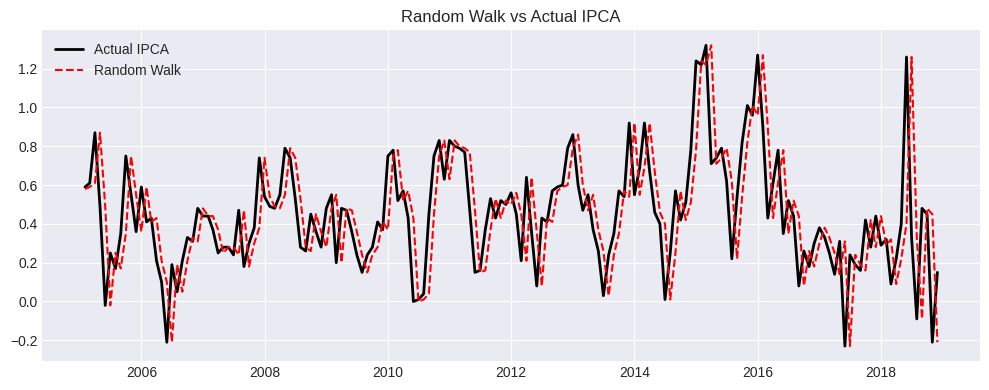


Random Walk Metrics:
RMSE:      0.2499
MAE:       0.1911
MSLE:      0.0089
R-Squared: 0.2029


In [5]:
# Random Walk (Baseline)
print("Training Random Walk baseline...")

dates_to_predict = y.index[12:] # Start forecasting after 1 year
rw_predictions = []

# Expanding window forecasting
for i in range(len(dates_to_predict)):
    # Random walk predicts the last known value
    y_train = y.iloc[:12+i]
    pred = y_train.iloc[-1] 
    rw_predictions.append(pred)

y_true = y.loc[dates_to_predict].values
y_pred_rw = np.array(rw_predictions)

# Plot predictions vs actual
plt.figure(figsize=(10, 4))
plt.plot(dates_to_predict, y_true, label='Actual IPCA', color='black', linewidth=2)
plt.plot(dates_to_predict, y_pred_rw, label='Random Walk', color='red', linestyle='--')
plt.title('Random Walk vs Actual IPCA')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate metrics
evaluate_model('Random Walk', y_true, y_pred_rw)

Training ARMA(1,1)...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used

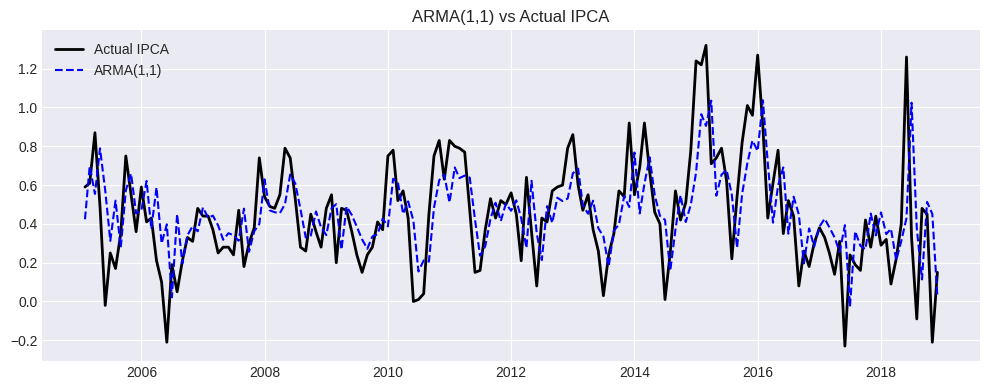


ARMA(1,1) Metrics:
RMSE:      0.2343
MAE:       0.1807
MSLE:      0.0077
R-Squared: 0.2993

Diebold-Mariano Test (ARMA(1,1) vs Random Walk):
DM-Statistic: 1.5318 | p-value: 0.0628
Result: No statistically significant improvement.


In [6]:
# ARMA(1,1)
from statsmodels.tsa.arima.model import ARIMA
print("Training ARMA(1,1)...")

arma_predictions = []

# Expanding window forecasting
for i in range(len(dates_to_predict)):
    y_train = y.iloc[:12+i]
    
    # Fit ARMA(1,1) as ARIMA(1,0,1)
    try:
        model = ARIMA(y_train, order=(1,0,1))
        fitted = model.fit()
        pred = fitted.forecast(steps=1).iloc[0]
    except:
        # Fallback to random walk if convergence fails
        pred = y_train.iloc[-1]
        
    arma_predictions.append(pred)

y_pred_arma = np.array(arma_predictions)

# Plot predictions vs actual
plt.figure(figsize=(10, 4))
plt.plot(dates_to_predict, y_true, label='Actual IPCA', color='black', linewidth=2)
plt.plot(dates_to_predict, y_pred_arma, label='ARMA(1,1)', color='blue', linestyle='--')
plt.title('ARMA(1,1) vs Actual IPCA')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate metrics
evaluate_model('ARMA(1,1)', y_true, y_pred_arma)

# Run Diebold-Mariano test
run_dm_test('ARMA(1,1)', y_true, y_pred_arma)

Training Phillips Curve...


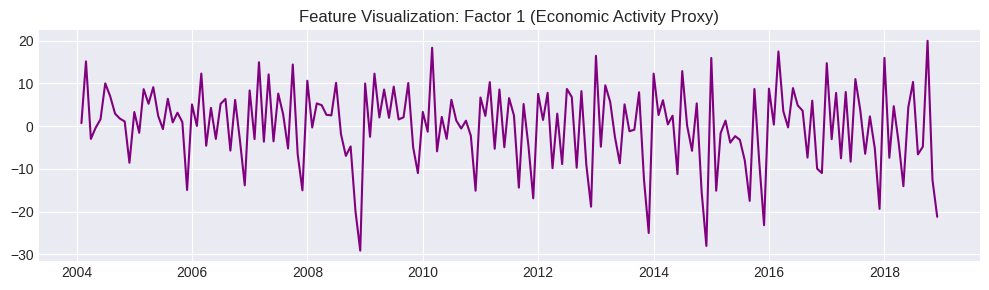

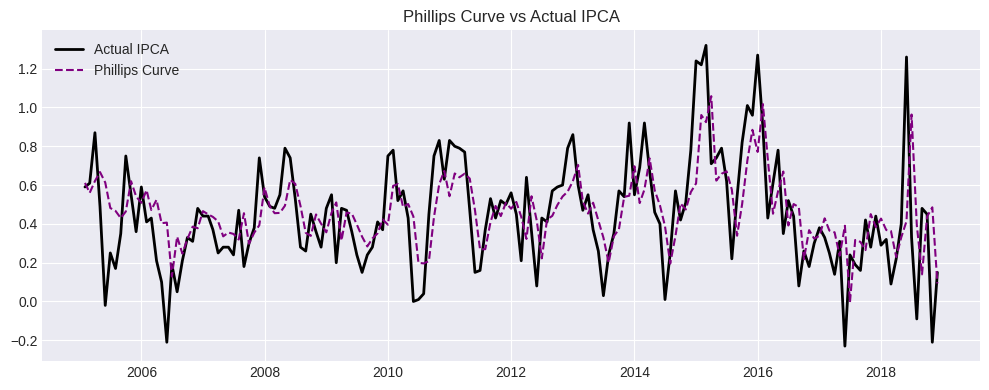


Phillips Curve Metrics:
RMSE:      0.2317
MAE:       0.1750
MSLE:      0.0076
R-Squared: 0.3147

Diebold-Mariano Test (Phillips Curve vs Random Walk):
DM-Statistic: 1.6585 | p-value: 0.0486
Result: Statistically significant improvement over baseline.


In [7]:
# Phillips Curve
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression

print("Training Phillips Curve...")

phillips_predictions = []

# Plot PCA Factor 1 (Economic Activity Proxy)
pca = PCA(n_components=1)
economic_activity = pca.fit_transform(X)

plt.figure(figsize=(10, 3))
plt.plot(X.index, economic_activity, color='purple')
plt.title('Feature Visualization: Factor 1 (Economic Activity Proxy)')
plt.tight_layout()
plt.show()

# Expanding window forecasting
for i in range(len(dates_to_predict)):
    X_train_full = X.iloc[:12+i]
    y_train = y.iloc[:12+i]
    X_test_full = X.iloc[[12+i]]
    
    # Extract Factor 1 from training data
    f1_train = pca.fit_transform(X_train_full)
    f1_test = pca.transform(X_test_full)
    
    # Features: [Past Inflation, Economic Activity]
    past_inf_train = y_train.shift(1).fillna(0).values.reshape(-1, 1)
    train_features = np.hstack((past_inf_train, f1_train))
    
    past_inf_test = np.array([[y_train.iloc[-1]]])
    test_features = np.hstack((past_inf_test, f1_test))
    
    # Fit Linear Regression
    pc_model = LinearRegression()
    pc_model.fit(train_features, y_train)
    pred = pc_model.predict(test_features)[0]
    
    phillips_predictions.append(pred)

y_pred_pc = np.array(phillips_predictions)

# Plot predictions vs actual
plt.figure(figsize=(10, 4))
plt.plot(dates_to_predict, y_true, label='Actual IPCA', color='black', linewidth=2)
plt.plot(dates_to_predict, y_pred_pc, label='Phillips Curve', color='purple', linestyle='--')
plt.title('Phillips Curve vs Actual IPCA')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate metrics and DM test
evaluate_model('Phillips Curve', y_true, y_pred_pc)
run_dm_test('Phillips Curve', y_true, y_pred_pc)

Training FAVAR...


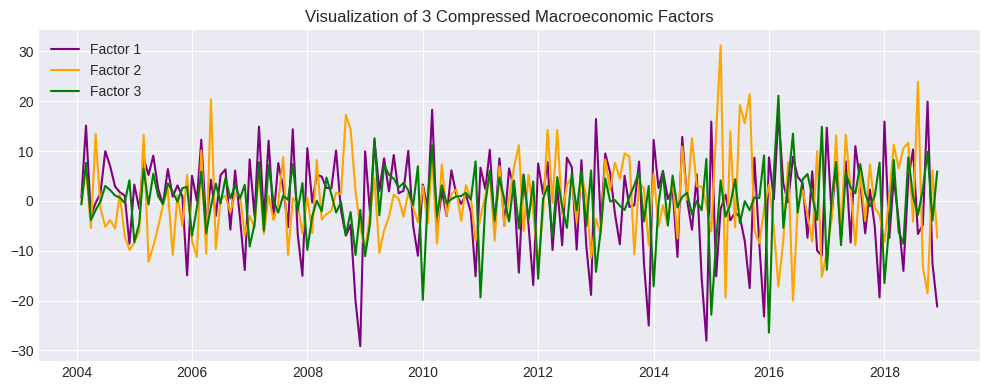

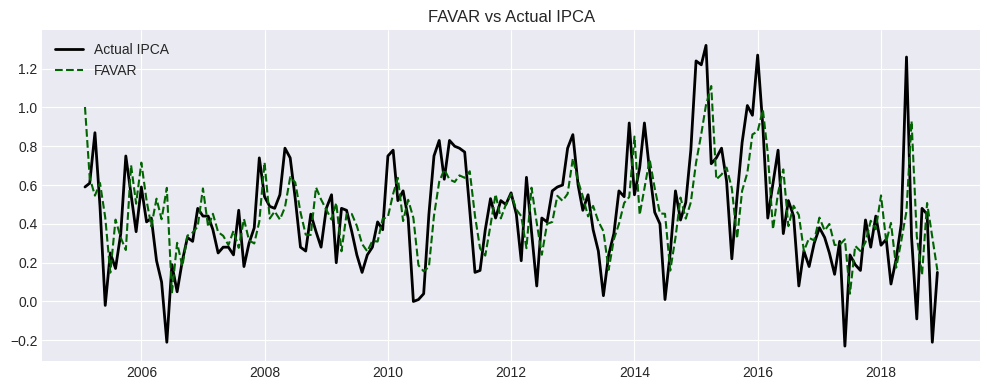


FAVAR Metrics:
RMSE:      0.2322
MAE:       0.1796
MSLE:      0.0076
R-Squared: 0.3120

Diebold-Mariano Test (FAVAR vs Random Walk):
DM-Statistic: 1.4437 | p-value: 0.0744
Result: No statistically significant improvement.


In [9]:
# Factor-Augmented VAR (FAVAR)
from statsmodels.tsa.api import VAR
from sklearn.decomposition import PCA

print("Training FAVAR...")

# Plot 3 PCA macroeconomic factors
pca_full = PCA(n_components=3)
factors_full = pca_full.fit_transform(X)

plt.figure(figsize=(10, 4))
plt.plot(X.index, factors_full[:, 0], label='Factor 1', color='purple')
plt.plot(X.index, factors_full[:, 1], label='Factor 2', color='orange')
plt.plot(X.index, factors_full[:, 2], label='Factor 3', color='green')
plt.title('Visualization of 3 Compressed Macroeconomic Factors')
plt.legend()
plt.tight_layout()
plt.show()

# Expanding window forecasting
favar_predictions = []
dates_to_predict = y.index[12:]

for i in range(len(dates_to_predict)):
    X_train_full = X.iloc[:12+i]
    y_train = y.iloc[:12+i]
    X_test_full = X.iloc[[12+i]]
    
    # Extract 3 factors from training data
    pca = PCA(n_components=3, random_state=42)
    factors_train = pca.fit_transform(X_train_full)
    factors_test = pca.transform(X_test_full)
    
    # Combine factors and inflation data
    var_data = pd.DataFrame(factors_train, columns=['Factor1', 'Factor2', 'Factor3'])
    var_data['Inflation'] = y_train.values
    
    # Fit VAR model (lag = 1)
    try:
        var_model = VAR(var_data)
        var_fitted = var_model.fit(1)
        
        # Predict the next month
        forecast = var_fitted.forecast(var_data.values[-1:], steps=1)
        # Inflation is the 4th column (index 3)
        pred = forecast[0][3] 
    except:
        # Fallback to random walk if convergence fails
        pred = y_train.iloc[-1]
        
    favar_predictions.append(pred)

y_pred_favar = np.array(favar_predictions)
y_true = y.loc[dates_to_predict].values

# Plot predictions vs actual
plt.figure(figsize=(10, 4))
plt.plot(dates_to_predict, y_true, label='Actual IPCA', color='black', linewidth=2)
plt.plot(dates_to_predict, y_pred_favar, label='FAVAR', color='darkgreen', linestyle='--')
plt.title('FAVAR vs Actual IPCA')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate metrics and DM test
evaluate_model('FAVAR', y_true, y_pred_favar)
run_dm_test('FAVAR', y_true, y_pred_favar)

Training LASSO...


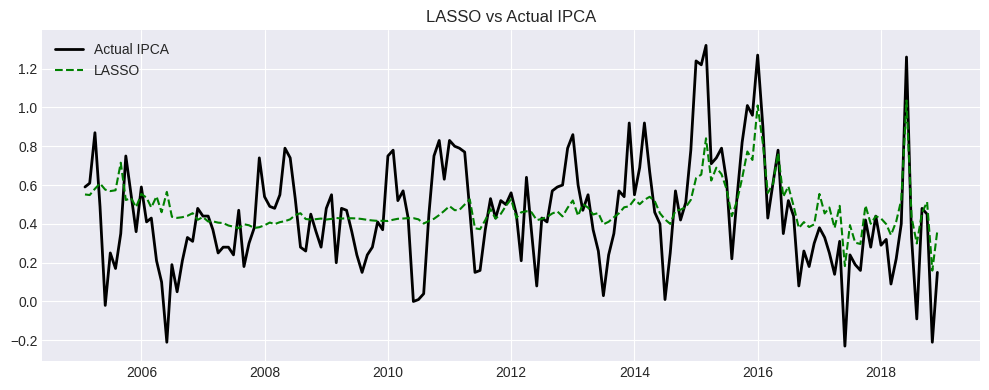


LASSO Metrics:
RMSE:      0.2237
MAE:       0.1744
MSLE:      0.0071
R-Squared: 0.3612

Diebold-Mariano Test (LASSO vs Random Walk):
DM-Statistic: 1.2881 | p-value: 0.0989
Result: No statistically significant improvement.


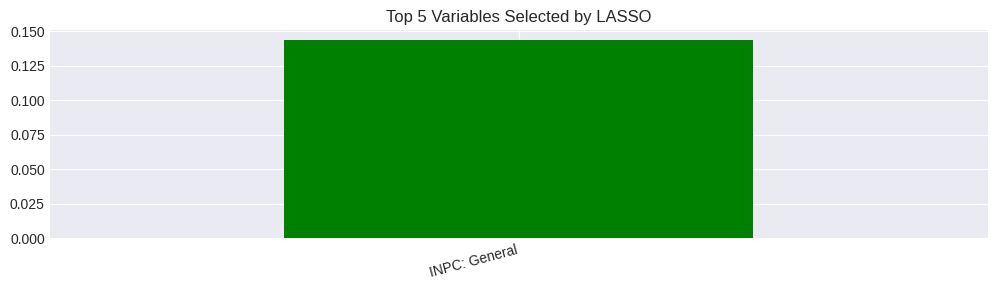

In [10]:
# LASSO Regression
from sklearn.linear_model import Lasso

print("Training LASSO...")
dates_to_predict = y.index[12:]
lasso_preds = []

# Expanding window forecasting
for i in range(len(dates_to_predict)):
    X_train = X.iloc[:12+i]
    y_train = y.iloc[:12+i]
    X_test = X.iloc[[12+i]]
    
    lasso = Lasso(alpha=0.1, random_state=42)
    lasso.fit(X_train, y_train)
    lasso_preds.append(lasso.predict(X_test)[0])

y_pred_lasso = np.array(lasso_preds)
y_true = y.loc[dates_to_predict].values

# Plot predictions vs actual
plt.figure(figsize=(10, 4))
plt.plot(dates_to_predict, y_true, label='Actual IPCA', color='black', linewidth=2)
plt.plot(dates_to_predict, y_pred_lasso, label='LASSO', color='green', linestyle='--')
plt.title('LASSO vs Actual IPCA')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate metrics and DM test
evaluate_model('LASSO', y_true, y_pred_lasso)
run_dm_test('LASSO', y_true, y_pred_lasso)

# Plot feature importances (Top 5 variables kept by LASSO)
coefs = pd.Series(lasso.coef_, index=X.columns)
top_coefs = coefs[coefs != 0].abs().sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 3))
top_coefs.plot(kind='bar', color='green')
plt.title('Top 5 Variables Selected by LASSO')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

Training Ridge...


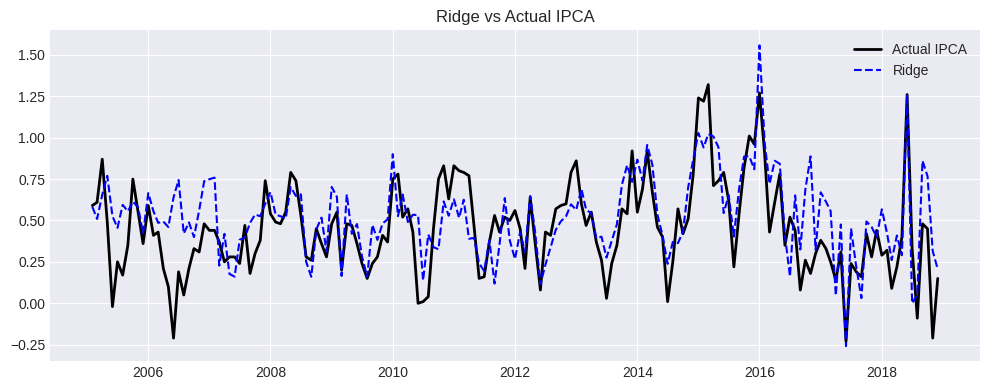


Ridge Metrics:
RMSE:      0.2213
MAE:       0.1734
MSLE:      0.0068
R-Squared: 0.3750

Diebold-Mariano Test (Ridge vs Random Walk):
DM-Statistic: 1.3662 | p-value: 0.0859
Result: No statistically significant improvement.


In [11]:
# Ridge Regression
from sklearn.linear_model import Ridge

print("Training Ridge...")
ridge_preds = []

# Expanding window forecasting
for i in range(len(dates_to_predict)):
    X_train = X.iloc[:12+i]
    y_train = y.iloc[:12+i]
    X_test = X.iloc[[12+i]]
    
    ridge = Ridge(alpha=1.0, random_state=42)
    ridge.fit(X_train, y_train)
    ridge_preds.append(ridge.predict(X_test)[0])

y_pred_ridge = np.array(ridge_preds)

# Plot predictions vs actual
plt.figure(figsize=(10, 4))
plt.plot(dates_to_predict, y_true, label='Actual IPCA', color='black', linewidth=2)
plt.plot(dates_to_predict, y_pred_ridge, label='Ridge', color='blue', linestyle='--')
plt.title('Ridge vs Actual IPCA')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate metrics and DM test
evaluate_model('Ridge', y_true, y_pred_ridge)
run_dm_test('Ridge', y_true, y_pred_ridge)

Training Elastic Net...


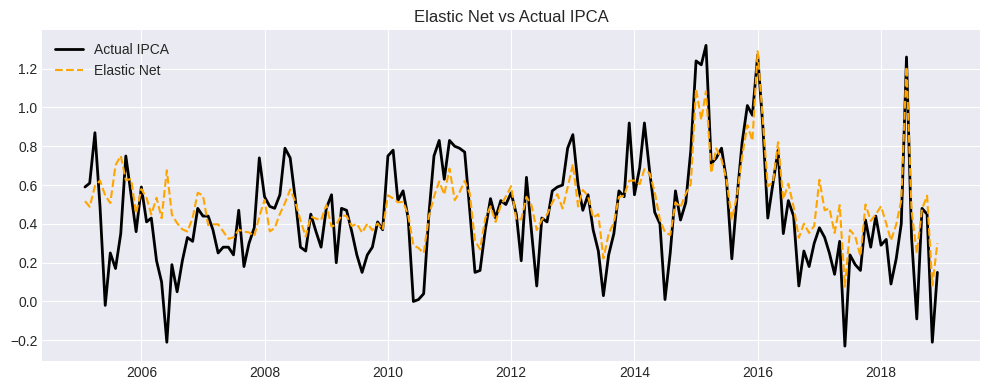


Elastic Net Metrics:
RMSE:      0.1783
MAE:       0.1335
MSLE:      0.0048
R-Squared: 0.5943

Diebold-Mariano Test (Elastic Net vs Random Walk):
DM-Statistic: 3.1551 | p-value: 0.0008
Result: Statistically significant improvement over baseline.


In [12]:
# Elastic Net
from sklearn.linear_model import ElasticNet

print("Training Elastic Net...")
enet_preds = []

# Expanding window forecasting
for i in range(len(dates_to_predict)):
    X_train = X.iloc[:12+i]
    y_train = y.iloc[:12+i]
    X_test = X.iloc[[12+i]]
    
    enet = ElasticNet(alpha=0.1, l1_ratio=0.5, random_state=42)
    enet.fit(X_train, y_train)
    enet_preds.append(enet.predict(X_test)[0])

y_pred_enet = np.array(enet_preds)

# Plot predictions vs actual
plt.figure(figsize=(10, 4))
plt.plot(dates_to_predict, y_true, label='Actual IPCA', color='black', linewidth=2)
plt.plot(dates_to_predict, y_pred_enet, label='Elastic Net', color='orange', linestyle='--')
plt.title('Elastic Net vs Actual IPCA')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate metrics and DM test
evaluate_model('Elastic Net', y_true, y_pred_enet)
run_dm_test('Elastic Net', y_true, y_pred_enet)

Training Random Forest...


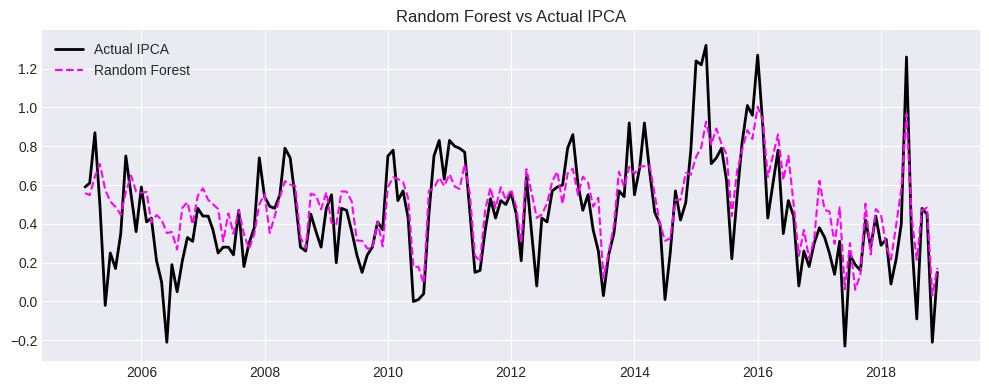


Random Forest Metrics:
RMSE:      0.1678
MAE:       0.1318
MSLE:      0.0040
R-Squared: 0.6408

Diebold-Mariano Test (Random Forest vs Random Walk):
DM-Statistic: 4.0435 | p-value: 0.0000
Result: Statistically significant improvement over baseline.


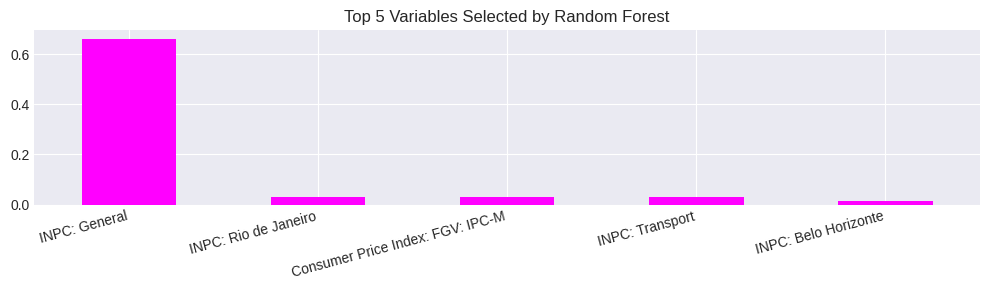

In [13]:
# Random Forest
from sklearn.ensemble import RandomForestRegressor

print("Training Random Forest...")
rf_preds = []

# Expanding window forecasting
for i in range(len(dates_to_predict)):
    X_train = X.iloc[:12+i]
    y_train = y.iloc[:12+i]
    X_test = X.iloc[[12+i]]
    
    rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    rf_preds.append(rf.predict(X_test)[0])

y_pred_rf = np.array(rf_preds)

# Plot predictions vs actual
plt.figure(figsize=(10, 4))
plt.plot(dates_to_predict, y_true, label='Actual IPCA', color='black', linewidth=2)
plt.plot(dates_to_predict, y_pred_rf, label='Random Forest', color='magenta', linestyle='--')
plt.title('Random Forest vs Actual IPCA')
plt.legend()
plt.tight_layout()
plt.show()

# Calculate metrics and DM test
evaluate_model('Random Forest', y_true, y_pred_rf)
run_dm_test('Random Forest', y_true, y_pred_rf)

# Plot feature importances (Top 5 variables selected by Random Forest)
importances = pd.Series(rf.feature_importances_, index=X.columns)
top_importances = importances.sort_values(ascending=False).head(5)

plt.figure(figsize=(10, 3))
top_importances.plot(kind='bar', color='magenta')
plt.title('Top 5 Variables Selected by Random Forest')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()


Generating final leaderboard...

Final Metrics:


,Model,RMSE,MAE,MSLE,R2
0,Random Forest,0.167761,0.131841,0.003985,0.640810
1,Elastic Net,0.178287,0.133524,0.004775,0.594322
2,Ridge,0.221299,0.173437,0.006834,0.374969
3,LASSO,0.223718,0.174416,0.007130,0.361228
4,Phillips Curve,0.231724,0.174994,0.007580,0.314689
5,FAVAR,0.232181,0.179578,0.007569,0.311985
6,FAVAR,0.232181,0.179578,0.007569,0.311985
7,"ARMA(1,1)",0.234319,0.180727,0.007731,0.299255
8,Random Walk,0.249914,0.191099,0.008852,0.202877


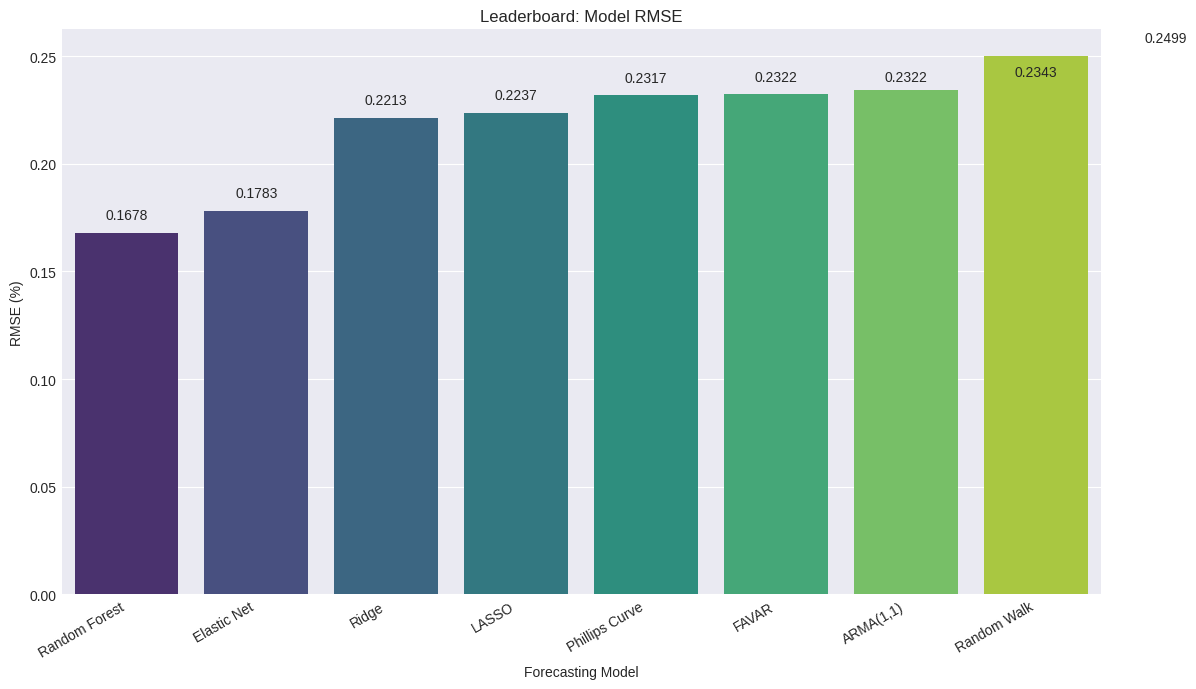

Best performing model: Random Forest (RMSE: 0.1678)


In [14]:
# Final Leaderboard
print("Generating final leaderboard...")

# Create and sort leaderboard dataframe
leaderboard_df = pd.DataFrame(leaderboard)
leaderboard_df = leaderboard_df.sort_values(by='RMSE', ascending=True).reset_index(drop=True)

print("\nFinal Metrics:")
display(leaderboard_df)

# Plot RMSE leaderboard
plt.figure(figsize=(12, 7))
ax = sns.barplot(x='Model', y='RMSE', data=leaderboard_df, palette='viridis')

plt.title('Leaderboard: Model RMSE')
plt.ylabel('RMSE (%)')
plt.xlabel('Forecasting Model')
plt.xticks(rotation=30, ha='right')

# Add values above bars
for i, score in enumerate(leaderboard_df['RMSE']):
    plt.text(i, score + 0.005, f"{score:.4f}", ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# Print best model
best_model = leaderboard_df.iloc[0]['Model']
best_rmse = leaderboard_df.iloc[0]['RMSE']
print(f"Best performing model: {best_model} (RMSE: {best_rmse:.4f})")